# Test Set Evaluation

Evaluate the trained X-ray classifier on the held-out test split using seed `42`. The notebook reports test loss, accuracy, AUC, and plots the ROC curve.

This exact behavior is also included in the train.py pipeline, we leave it in here as legacy

In [4]:
from pathlib import Path
import os
import sys
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm
from omegaconf import OmegaConf
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.data.dataset import ChestXrayDataset, make_splits
from src.data.transforms import get_val_transform
from src.models.model import XRayClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

FORCE_CPU = False

cuda_available = torch.cuda.is_available()
device = torch.device("cuda" if cuda_available and not FORCE_CPU else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {cuda_available}")
if cuda_available:
    print(f"CUDA version:   {torch.version.cuda}")
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
else:
    print("GPU was not selected because this Python environment cannot see CUDA.")
    print("If you have an NVIDIA GPU, install/use a CUDA-enabled PyTorch environment for this notebook kernel.")

print(f"Selected device: {device}")

PyTorch version: 2.3.1+cu121
CUDA available: True
CUDA version:   12.1
GPU:            NVIDIA GeForce RTX 2070 SUPER
Selected device: cuda


## Configuration

The training config uses `/app/...` paths inside Docker. For local notebook use, this cell falls back to the repo-local `data/processed/binary_labels.csv`.

In [5]:
cfg = OmegaConf.load(PROJECT_ROOT / "configs" / "train.yaml")

csv_path = Path(cfg.data.csv_path)
if not csv_path.exists():
    csv_path = PROJECT_ROOT / "data" / "processed" / "binary_labels.csv"

model_path = Path(os.environ.get("MODEL_LOCAL_PATH", PROJECT_ROOT / "models" / cfg.paths.checkpoint_name))

print(f"CSV path:   {csv_path}")
print(f"Model path: {model_path}")
print(f"Device:     {device}")

assert csv_path.exists(), f"Missing labels CSV: {csv_path}. Run dvc pull or create the processed labels first."
assert model_path.exists(), f"Missing model checkpoint: {model_path}. Download/train the model first."

CSV path:   c:\Users\pasca\Projekt\X-Ray-Abnormality-Detector\data\processed\binary_labels.csv
Model path: c:\Users\pasca\Projekt\X-Ray-Abnormality-Detector\models\best_model.pt
Device:     cuda


## Create Test Split

This uses the same split function as training with `random_state=42`, then keeps only the held-out test dataframe. The hyperparameter-search code samples 20% of train/validation for speed, but this notebook does not sample the test set.

In [6]:
train_df, val_df, test_df = make_splits(
    csv_path,
    val_size=cfg.data.val_size,
    test_size=cfg.data.test_size,
    random_state=SEED,
)

print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Total rows: {len(train_df) + len(val_df) + len(test_df)}")
print("\nThe notebook uses the full test split. No sampling is applied to test_df.")
print("\nTest label distribution:")
display(test_df["target"].value_counts(normalize=True).rename("fraction"))

Train rows: 89696
Val rows:   11212
Test rows:  11212
Total rows: 112120

The notebook uses the full test split. No sampling is applied to test_df.

Test label distribution:


target
0    0.538352
1    0.461648
Name: fraction, dtype: float64

## Verify Held-Out Test Set

The test set should contain only samples that are not present in the training or validation splits.

In [7]:
train_val_paths = set(train_df["image_path"]) | set(val_df["image_path"])
test_paths = set(test_df["image_path"])
overlap = train_val_paths & test_paths

print(f"Train + validation samples: {len(train_df) + len(val_df)}")
print(f"Held-out test samples:      {len(test_df)}")
print(f"Overlap with train/val:     {len(overlap)}")

assert len(overlap) == 0, "Some test images are also present in train/validation."

Train + validation samples: 100908
Held-out test samples:      11212
Overlap with train/val:     0


## Load Model

In [8]:
def load_state_dict(path):
    state = torch.load(path, map_location=device)
    if isinstance(state, dict) and "state_dict" in state:
        return state["state_dict"]
    return state

model = XRayClassifier(
    model_name=cfg.model.name,
    dropout=cfg.model.dropout,
    pretrained=False,
).to(device)

model.load_state_dict(load_state_dict(model_path))
model.eval()

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([cfg.loss.pos_weight], device=device)
)

print("Model loaded.")

Model loaded.


## Evaluate on Test Set

In [9]:
test_dataset = ChestXrayDataset(test_df, transform=get_val_transform())
test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.training.batch_size * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print(f"Evaluating all {len(test_dataset)} test images in {len(test_loader)} batches.")

all_probs = []
all_labels = []
losses = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, total=len(test_loader), desc="Evaluating test set"):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        logits = model(imgs)
        loss = criterion(logits, labels)
        probs = torch.sigmoid(logits)

        losses.append(loss.item())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.asarray(all_probs)
all_labels = np.asarray(all_labels).astype(int)
all_preds = (all_probs >= 0.5).astype(int)

test_loss = float(np.mean(losses))
test_accuracy = float(accuracy_score(all_labels, all_preds))
test_auc = float(roc_auc_score(all_labels, all_probs))

metrics = {
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "test_auc": test_auc,
}

metrics

Evaluating all 11212 test images in 176 batches.


Evaluating test set: 100%|██████████| 176/176 [03:05<00:00,  1.06s/it]


{'test_loss': 0.6170361638069153,
 'test_accuracy': 0.7221726721369961,
 'test_auc': 0.7836486682685955}

## ROC Curve

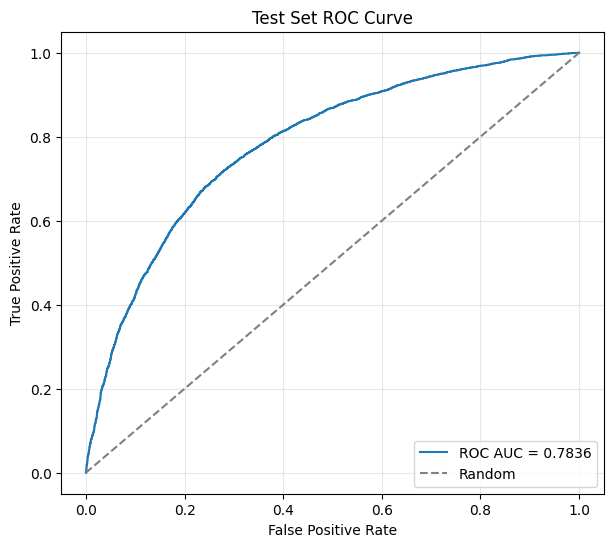

In [10]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test Set ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Optional: Find Best Accuracy Threshold

In [11]:
candidate_thresholds = np.linspace(0.0, 1.0, 101)
accuracies = [accuracy_score(all_labels, all_probs >= threshold) for threshold in candidate_thresholds]
best_idx = int(np.argmax(accuracies))

{
    "best_test_accuracy_threshold": float(candidate_thresholds[best_idx]),
    "best_test_accuracy": float(accuracies[best_idx]),
    "accuracy_at_0_5": test_accuracy,
}

{'best_test_accuracy_threshold': 0.5,
 'best_test_accuracy': 0.7221726721369961,
 'accuracy_at_0_5': 0.7221726721369961}

In [12]:
idx = np.argmin(np.abs(thresholds - 0.5))

print("Threshold:", thresholds[idx])
print("TPR:", tpr[idx])
print("FPR:", fpr[idx])

Threshold: 0.4995993
TPR: 0.6810278207109737
FPR: 0.24271040424121934
